<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day02_practice2_%EA%B2%BD%EC%82%AC%ED%95%98%EA%B0%95_%EC%84%A0%ED%98%95%ED%9A%8C%EA%B7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 경사하강법으로 선형회쉬 - 딥러닝의 방식

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False # 마이너스 부호 깨짐 방지 설정
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
# 셀 1. 교재 4장의 데이터 - 공부 시간과 성적
x = torch.tensor([[2.0],[4.0],[6.0],[8.0]])           # 공부 시간 (4개)
y = torch.tensor([[81.0],[93.0],[91.0],[97.0]]) # 성적 (4개)

# PyTorch 모델은 (데이터 개수, 특징 개수) 형태로 입력
# (4,1) -> 데이터 4개 x 특징 1개

In [8]:
# 셀 2. 방법(1) - 수동 경사하강 ( 공식 없이 a, b 찾아가기)

a = torch.zeros(1, requires_grad=True) # 아무 값에서 출발 (0)
b = torch.zeros(1, requires_grad=True)

ir = 0.03                              # 학습용

for epoch in range(2001):
  pred = a * x + b                     # 1. 예측
  loss = ((y - pred) ** 2).mean()      # 2. 손실 = MSE

  loss.backward()                      # 3. 역전파, a 와 b 구하기

  with torch.no_grad():                # 4. 갱신 (기울기 반대 방향)
    a -= ir * a.grad
    b -= ir * b.grad

  a.grad.zero_()                     # 5. 기울기 초기화
  b.grad.zero_()

  if epoch % 400 == 0:
    print(f"epoch {epoch:4d} | a={a.item():.3f} b={b.item():.3f} | MSE={loss.item():.2f}")

epoch    0 | a=27.840 b=5.430 | MSE=8225.00
epoch  400 | a=2.554 b=77.483 | MSE=8.69
epoch  800 | a=2.305 b=78.970 | MSE=8.30
epoch 1200 | a=2.300 b=78.999 | MSE=8.30
epoch 1600 | a=2.300 b=79.000 | MSE=8.30
epoch 2000 | a=2.300 b=79.000 | MSE=8.30


In [6]:
# 셀 3. 방법(2) - nn.Linear + costimizer (PyTorch 정식 방식)

import torch.nn as nn
import torch.optim as optim

x = torch.tensor([[2.0],[4.0],[6.0],[8.0]]) # 공부 시간 (4개)
y = torch.tensor([[81.0],[93.0],[91.0],[97.0]]) # 성적 (4개)

model = nn.Linear(1,1)
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

print("\n 학습전 파라미터(난수):",
      f"w={model.weight.item():.3f}, b={model.bias.item():.3f}")

for epoch in range(2001):       # 1. 예측(내부: x @ w + b)
  pred = model(x)               # 2. 손실 = MSE
  loss = loss_fn(pred, y)       #

  optimizer.zero_grad()         # 5. 기울기 초기
  loss.backward()               # 3. 역전파 a 와 b의 미분값 구하기
  optimizer.step()              # 4. 갱신 (기울기 반대 방향)

  if epoch % 400 == 0:
    print(f"epoch {epoch:4d} | MSE={loss.item():.2f}")

print(f"nn.Linear 결과: w = {model.weight.item():.2f}, b={model.bias.item():.2f}")


 학습전 파라미터(난수): w=0.765, b=0.830
epoch    0 | MSE=7389.85
epoch  400 | MSE=746.87
epoch  800 | MSE=578.08
epoch 1200 | MSE=447.87
epoch 1600 | MSE=347.41
epoch 2000 | MSE=269.91
nn.Linear 결과: w = 8.94, b=39.40


In [9]:
# 셀 4. 방법(3) - 다중 선형회귀
# 변수 추가: 공부시간 + 과외 횟수 -> 성적

x2 = torch.tensor([[2.0,0.0],
                   [4.0,4.0],
                   [6.0,2.0],
                   [8.0,3.0]])  # (4,2) - 특징이 2개
y2 = torch.tensor([[81.0],[93.0],[91.0],[97.0]])

model2 = nn.Linear(2,1)
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model2.parameters(), lr=0.02)
print("\n 학습전 파라미터(난수):",
      f"w1={model2.weight[0][0].item():.3f}, w2={model2.weight[0][1].item():.3f}, b={model2.bias.item():.3f}")

for epoch in range(2001):       # 1. 예측(내부: x @ w + b)
  pred = model2(x2)
  loss = loss_fn(pred, y2)
  optimizer.zero_grad()         # 5. 기울기 초기
  loss.backward()               # 3. 역전파 a 와 b의 미분값 구하기
  optimizer.step()              # 4. 갱신 (기울기 반대 방향)

  if epoch % 400 == 0:
    print(f"epoch {epoch:4d} | MSE={loss.item():.2f}")

w1, w2 = model2.weight[0]
print(f"\n다중 회귀: 성적 = {w1.item():.2f} x 공부시간 + {w2.item():.2f} x 과외횟수 + {model2.bias.item():.2f}")
print(f"최종 MSE: {loss.item():.4f}")


 학습전 파라미터(난수): w1=-0.166, w2=0.650, b=-0.155
epoch    0 | MSE=8133.25
epoch  400 | MSE=5.82
epoch  800 | MSE=0.11
epoch 1200 | MSE=0.07
epoch 1600 | MSE=0.07
epoch 2000 | MSE=0.07

다중 회귀: 성적 = 1.50 x 공부시간 + 2.29 x 과외횟수 + 77.86
최종 MSE: 0.0714


SGD  lr=0.03   1000 epoch 후 MSE: 8.30
SGD  lr=0.001  1000 epoch 후 MSE: 518.14
Adam lr=1.0    1000 epoch 후 MSE: 8.30
Adam lr=0.1    1000 epoch 후 MSE: 293.50
AdamW lr=0.1    1000 epoch 후 MSE: 435.88


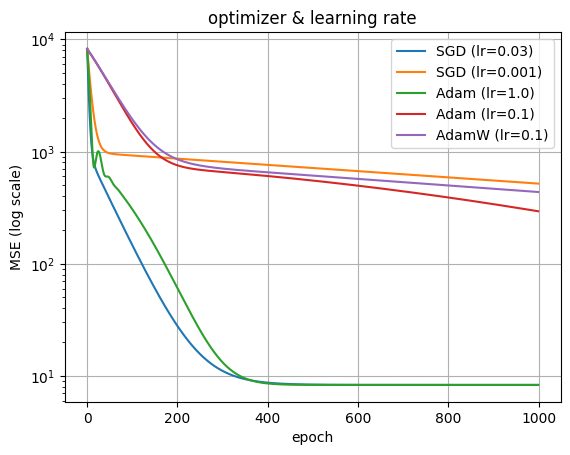

In [14]:
# 셀 5. SGD vs Adam - 옵티마이저 비교

# 옵티마이저 = "한 걸음을 어떻게 걸을까" 전략
# SGD: 기울기 그대로 한 걸음(기본형)
# Adam: 걸음 크기를 상황에 맞게 자동 조절, 관성, 보폭 조절 (실무 기본값)
# AdamW : Adam의 Weight 개선 (최신 모델 많이 사용)

def train(opt_name, lr, epochs=1000):
  m = nn.Linear(1,1)
  torch.nn.init.zeros_(m.weight); torch.nn.init.zeros_(m.bias) # weight를 전부 0으로, bias를 0으로 PyTorch에서 _로 끝나는 함수는 원본 텐서를 직접 바꾼다

  if opt_name == "SGD":
    opt = torch.optim.SGD(m.parameters(), lr=lr)
  elif opt_name == "Adam":
    opt = torch.optim.Adam(m.parameters(), lr=lr)
  elif opt_name == "AdamW":
    opt = torch.optim.AdamW(m.parameters(), lr=lr)

  losses = []
  for _ in range(epochs):
    loss = nn.functional.mse_loss(m(x),y)
    opt.zero_grad();
    loss.backward()
    opt.step()
    losses.append(loss.item())
  return losses

# 각 옵티마이저가 잘 작동하는 학습률을 하나씩 돌라 비교
for name, lr in [("SGD", 0.03), ("SGD", 0.001), ("Adam", 1.0), ("Adam",0.1), ("AdamW", 0.1)]:
  losses = train(name, lr)
  plt.plot(losses, label=f"{name} (lr={lr})")
  print(f"{name:4s} lr={lr:<6} 1000 epoch 후 MSE: {losses[-1]:.2f}")

plt.xlabel("epoch"); plt.ylabel("MSE (log scale)"); plt.legend(); plt.grid(True)
plt.yscale("log")
plt.title("optimizer & learning rate")
plt.savefig("plot3_optimizers.png")
plt.show()

# 같은 옵티마이저라도 학습률에 따라 속도가 극적으로 다르다. 1000 epoch로는 부족